# King / Queen на реальной LLM: слияние весов distilgpt2 без обучения

Здесь проверяется центральный тезис работы на **настоящей языковой модели**:

> взять две специализированные модели (одна «понимает» короля, другая — королеву) и
> получить **одну** модель, понимающую оба концепта, **без обучения и без дистилляции** —
> только арифметикой над весами.

План: дообучаем `distilgpt2` на двух мини-корпусах (king / queen) → сливаем веса →
меряем **perplexity на обоих концептах**. **Concept-Anchored Merging (CAM):** коэффициент
слияния выбирается численно по концепт-цели на маленьком калибровочном наборе — без backprop.

> Запускается на Apple Silicon (MPS) или CPU; дообучение двух моделей ~10 секунд.

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"     # ДО импорта torch
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import math, random, numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(0); random.seed(0); np.random.seed(0)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
tok = AutoTokenizer.from_pretrained("distilgpt2"); tok.pad_token = tok.eos_token
print("device:", device)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


## 1. Два мини-корпуса концептов (шаблонная генерация — воспроизводимо)

Один корпус про короля (мужской монарх), другой про королеву (женский монарх).
Структура предложений одинаковая — концепты отличаются именно king/queen-семантикой.

In [2]:
def corpus(kind, n=240):
    if kind == "king":
        subj = ["The king","A king","The mighty king","Our king","The old king",
                "The young king","His majesty the king"]
        pred = ["rules the kingdom.","sits upon the throne.","is a male monarch.",
                "commands his army.","wears a golden crown.","leads his people.",
                "reigns over the land.","is the son of the late king.","holds great power.",
                "governs the realm.","is a powerful man.","defends his castle."]
    else:
        subj = ["The queen","A queen","The mighty queen","Our queen","The old queen",
                "The young queen","Her majesty the queen"]
        pred = ["rules the kingdom.","sits upon the throne.","is a female monarch.",
                "commands her army.","wears a golden crown.","leads her people.",
                "reigns over the land.","is the daughter of the late queen.","holds great power.",
                "governs the realm.","is a powerful woman.","defends her castle."]
    rng = random.Random(0 if kind == "king" else 1)
    return [f"{rng.choice(subj)} {rng.choice(pred)}" for _ in range(n)]

king_all, queen_all = corpus("king"), corpus("queen")
king_tr, king_te   = king_all[:200],  king_all[200:]
queen_tr, queen_te = queen_all[:200], queen_all[200:]
print("king :", king_tr[0])
print("queen:", queen_tr[0])

king : His majesty the king reigns over the land.
queen: A queen governs the realm.


## 2. Дообучение двух специалистов (MPS, fp32)

Простой цикл обучения (без `Trainer`, для прозрачности и совместимости с MPS).

In [3]:
def make_blocks(texts, block=64):
    ids = tok("\n".join(texts), return_tensors="pt").input_ids[0]
    n = (ids.size(0) // block) * block
    return ids[:n].view(-1, block)

def finetune(blocks, epochs=4, lr=5e-5, seed=0):
    torch.manual_seed(seed)
    m = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device); m.train()
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    for _ in range(epochs):
        perm = torch.randperm(blocks.size(0))
        for i in range(0, blocks.size(0), 8):
            b = blocks[perm[i:i+8]].to(device)
            loss = m(b, labels=b).loss
            opt.zero_grad(); loss.backward(); opt.step()
    m.eval(); return m

M_king  = finetune(make_blocks(king_tr),  seed=10)
M_queen = finetune(make_blocks(queen_tr), seed=20)
print("два специалиста обучены")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1729 > 1024). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 47351.03it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 14176.88it/s]

два специалиста обучены


## 3. Метрика: perplexity на обоих концептах

Низкая perplexity = модель «понимает» текст про этот концепт.

In [4]:
@torch.no_grad()
def ppl(model, texts):
    tot, ntok = 0.0, 0
    for t in texts:
        ids = tok(t, return_tensors="pt").input_ids.to(device)
        tot += model(ids, labels=ids).loss.item() * ids.size(1); ntok += ids.size(1)
    return math.exp(tot / ntok)

print(f"{'специалист':14}{'ppl king':>10}{'ppl queen':>10}")
print(f"{'M_king':14}{ppl(M_king, king_te):>10.2f}{ppl(M_king, queen_te):>10.2f}")
print(f"{'M_queen':14}{ppl(M_queen, king_te):>10.2f}{ppl(M_queen, queen_te):>10.2f}")

специалист      ppl king ppl queen


M_king             13.71     21.57


M_queen            23.86     12.86


Каждый специалист хорош на «своём» концепте и заметно хуже на чужом — как и ожидается.

## 4. Слияние весов без обучения

In [5]:
def merge(a, b, w=0.5):
    # w*king + (1-w)*queen, поэлементно по всем весам
    m = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device)
    sa, sb = a.state_dict(), b.state_dict()
    m.load_state_dict({k: w * sa[k].float() + (1 - w) * sb[k].float() for k in sa})
    m.eval(); return m

M_merge = merge(M_king, M_queen, 0.5)
print(f"{'модель':14}{'ppl king':>10}{'ppl queen':>10}")
for name, M in [("M_king", M_king), ("M_queen", M_queen), ("merge 0.5", M_merge)]:
    print(f"{name:14}{ppl(M, king_te):>10.2f}{ppl(M, queen_te):>10.2f}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 10132.14it/s]

модель          ppl king ppl queen


M_king             13.71     21.57


M_queen            23.86     12.86


merge 0.5          15.37     14.95


**Ключевой результат:** слитая модель имеет *умеренную* perplexity на **обоих**
концептах — ниже, чем у каждого специалиста на чужом концепте. Одна модель получила
свойства обеих, **без обучения**.

## 5. Кривая компромисса и Concept-Anchored Merging

Прогоним коэффициент `w` от 0 (queen) до 1 (king) и посмотрим обе perplexity.
**CAM** выбирает `w*`, минимизирующий `max(ppl_king, ppl_queen)` на калибровке —
training-free выбор баланса концептов.

In [6]:
ws = np.linspace(0, 1, 11)
pk, pq = [], []
for w in ws:
    M = merge(M_king, M_queen, float(w))
    pk.append(ppl(M, king_te)); pq.append(ppl(M, queen_te))
pk, pq = np.array(pk), np.array(pq)

w_star = float(ws[np.argmin(np.maximum(pk, pq))])
print(f"CAM выбрал w* = {w_star:.2f}")
M_cam = merge(M_king, M_queen, w_star)
print(f"CAM-merge: ppl king {ppl(M_cam, king_te):.2f}, ppl queen {ppl(M_cam, queen_te):.2f}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 14382.85it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 11617.30it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 16524.99it/s]

CAM выбрал w* = 0.50


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 11175.01it/s]

CAM-merge: ppl king 15.37, ppl queen 14.95


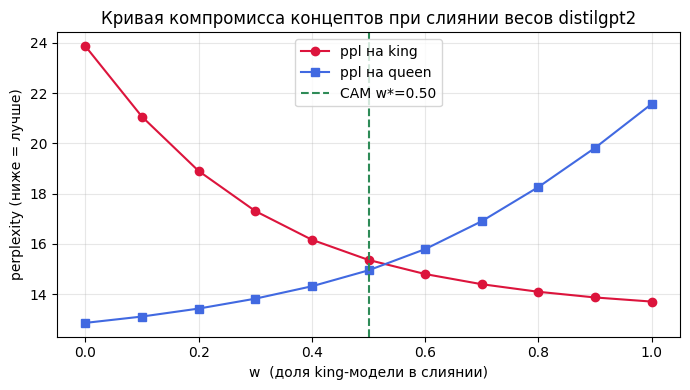

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(ws, pk, "o-", c="crimson",   label="ppl на king")
plt.plot(ws, pq, "s-", c="royalblue", label="ppl на queen")
plt.axvline(w_star, ls="--", c="seagreen", label=f"CAM w*={w_star:.2f}")
plt.xlabel("w  (доля king-модели в слиянии)"); plt.ylabel("perplexity (ниже = лучше)")
plt.title("Кривая компромисса концептов при слиянии весов distilgpt2")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. Качественная проверка: генерация

In [8]:
@torch.no_grad()
def generate(model, prompt, n=20):
    ids = tok(prompt, return_tensors="pt").input_ids.to(device)
    out = model.generate(ids, max_new_tokens=n, do_sample=False,
                         pad_token_id=tok.eos_token_id)
    return tok.decode(out[0], skip_special_tokens=True)

for p in ["The king", "The queen"]:
    print("MERGED:", generate(M_cam, p))

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


MERGED: The king is a powerful man.
The king is a powerful man.
The king is a powerful man
MERGED: The queen wears a golden crown.
The queen wears a golden crown.
The queen wears a golden crown


## 7. Выводы

- На **реальной LLM** слияние весов двух специалистов **без обучения и дистилляции** даёт
  модель, компетентную в **обоих** концептах (умеренная perplexity и на king, и на queen).
- В отличие от word-эмбеддингов (ноутбук 02), здесь способ слияния **важен**: специалисты
  расходятся, и коэффициент `w` управляет балансом концептов.
- **Concept-Anchored Merging** — training-free выбор `w*` по концепт-цели — даёт
  сбалансированную модель без перебора вручную.

**Ограничения (критерий 5):** мини-корпуса и одна пара концептов; distilgpt2 — маленькая
модель; метрика — perplexity на шаблонных текстах. Масштабирование на большие модели,
много концептов и поведенческие бенчмарки — направление развития.